## Dive Into Deep Learning Chapter Exploration

### 2.5 Auto Differentiation

##### 2.5.1 Notes
- automatic differentiaion works backwards by applying the chain rule (in what is known as backpropagation)
- 

In [1]:
import torch

In [3]:
x = torch.arange(4.0)
x.requires_grad_(True)
x.grad

In [29]:
y = 2 * torch.dot(x,x) 
y

tensor(28., grad_fn=<MulBackward0>)

In [ ]:
x.grad.zero_() #pytorch does not auto reset the gradient buffer
y.backward()
x.grad

#once you go backwards it saves that way so you cant run the code multiple times
# the two last commands in succession get us the gradient of y with respect to x 
#perhaps it goes backward then you must pick what to calculate w respect to in x.grad


tensor([ 0.,  4.,  8., 12.])

In [31]:
x.grad == 4 * x

tensor([True, True, True, True])

In [40]:
x.grad.zero_()
y = x.sum() 
y.backward()
x.grad


tensor([1., 1., 1., 1.])

##### 2.5.2 Notes
- we need to provide some vector v such that the backward will compute v^T PDEx y instead of just PDEx y

In [39]:
x.grad.zero_()
y = x * x
y.backward(gradient=torch.ones(len(y))) 
x.grad

tensor([0., 2., 4., 6.])

##### 2.5.3 Notes
- Detaching computation (important in back propogation when the calculation of things are coupled together)
- example:
let z = x * y
let y = x * x
We want to find z dx 
To solve this issue we create a dummy variable thats creation/ancestors in the graph have been wiped out 
z = u *x dz/dx returns u rather than 3x^2

In [47]:
x.grad.zero_()
y = x * x
u = y.detach()
z = u * x
z.sum().backward()
x.grad == u

tensor([True, True, True, True])

In [ ]:
x.grad.zero_()
y.sum().backward() 
x.grad == 2 * x

tensor([True, True, True, True])

In [50]:
def f(a):
    b = a * 2
    while b.norm() < 1000:
        b = b * 2
    if b.sum() > 0:
        c = b
    else:
        c = 100 * b
    return c

In [ ]:
a = torch.randn(size = (), requires_grad =  True)
d = f(a)
d.backward() # what is this doing here Im confused
a.grad == d/a 

tensor(True)

Three basics to remember: 

(i) attach gradients to those variables with respect to which we desire derivatives 

x.requires_grad_(True)

(ii) record the computation of the target value 

y = x * x

(iii) execute the backpropogation function 

y.backward(gradient=torch.ones(len(y))) 

Note that this function requires y to be scalar --> so you need to apply something to make it a scalar if it is not already 

this is why when we were detaching computations we .sum() before we .backward() s

(iv) access the gradient (is a seperate thing then the original variable is stored as follows:)

x.grad

##### Excercises 2.5

1) You need to create memory for the intermediate steps (the first derivative) to also compute the second derivative

2) If we try to run the backward() function twice like below then we run into an error because you cant run backward through a graph twice (?)

In [54]:
x.grad.zero_()
y= x * x

In [ ]:
# y.sum().backward()
x.grad

tensor([0., 2., 4., 6.])

In [ ]:
a.grad.zero_()
d = f(x)
d.sum().backward() # what is this doing here Im confused
a.grad

'''
The result is a vector and thus the backward function 
cannot act on it

We could use the sum function or any other function that allows us to take this vector into a scalar
'''

tensor(0.)

In [65]:
import math
import matplotlib.pyplot as plt

x = torch.arange(-10,10,0.1, requires_grad= True)

y= torch.sin(x)

y.sum().backward()

x.grad

tensor([-0.8391, -0.8892, -0.9304, -0.9624, -0.9847, -0.9972, -0.9997, -0.9922,
        -0.9748, -0.9477, -0.9111, -0.8654, -0.8111, -0.7486, -0.6787, -0.6020,
        -0.5193, -0.4314, -0.3392, -0.2435, -0.1455, -0.0460,  0.0540,  0.1534,
         0.2513,  0.3466,  0.4385,  0.5261,  0.6084,  0.6845,  0.7539,  0.8157,
         0.8694,  0.9144,  0.9502,  0.9766,  0.9932,  0.9999,  0.9965,  0.9833,
         0.9602,  0.9275,  0.8855,  0.8347,  0.7756,  0.7087,  0.6347,  0.5544,
         0.4685,  0.3780,  0.2837,  0.1865,  0.0875, -0.0124, -0.1122, -0.2108,
        -0.3073, -0.4008, -0.4903, -0.5748, -0.6536, -0.7259, -0.7910, -0.8481,
        -0.8968, -0.9365, -0.9668, -0.9875, -0.9983, -0.9991, -0.9900, -0.9710,
        -0.9422, -0.9041, -0.8569, -0.8011, -0.7374, -0.6663, -0.5885, -0.5048,
        -0.4161, -0.3233, -0.2272, -0.1288, -0.0292,  0.0707,  0.1700,  0.2675,
         0.3624,  0.4536,  0.5403,  0.6216,  0.6967,  0.7648,  0.8253,  0.8776,
         0.9211,  0.9553,  0.9801,  0.99

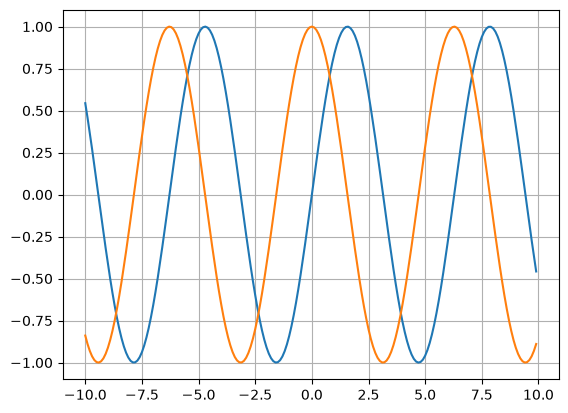

In [70]:
x_vals = x.detach().numpy()
y_vals = y.detach().numpy()
dy_vals = x.grad.numpy()

plt.plot(x_vals, y_vals)
plt.plot(x_vals, dy_vals)
plt.grid(True)
plt.show()

5)
g(x) = x^2          g'(x) = 2x
l(x) = log x        l'(x) = 1/(ln 10)(x)
s(x) = sin x        s'(x)= cos x
h(x) = x^-1         h'(x) = -x^-2

f(x) = (l(g(x)) * s(x)) + h(x)
6)
f'(x) = [(l(g(x)) * s(x))]' + h'(x)
f'(x) = [(l(g(x))]'s(x) + s'(x)(l(g(x))) + h'(x)
f'(x) = (l'(g(x))*g'(x))s(x) + s'(x)(l(g(x))) + h'(x)
f'(x) = ((2x)(sin x)/(ln 10)(x^2)) + (cos x)(log(x^2) + -x^-2

foward is when we go from the input and build up around it to the output

backward is when we start from the output and split it up into its functions till we get to the input

For 8) sources online say foward differentiation is best use for few inputs many outputs and backward differentiation is good for many inputs single/few outputs. This makes sense since we need to work out way to the outputs in forward differentiation and so starting small and getting larger is generally easier than trying to condense things. This is also true for backwards differentition. Also the less things you start with the less things you need to compute the differentiation on so for both cases the "input" is a small amount. 


#### 4.1 Softmax Regression
##### 4.1.1 Softmax
- in classification we are essentially assigning probabilites that an object belongs in each category
- there is a category vector for example for cat,chicken, dog we would have [1,0,0] for a cat and [0,1,0] for a chicken so on so forth
- The issue is that when we are going through the neural network to the outputs, we cannot garuntee that the outputs are non negative nor can we conclude that they sum to 1
- one solution to this is to say the the predicted values(o) are corrupted versions of the acutual value(y) --> so y = o + ~N(0, sigma^2) [normal dist]
- another solution is to use the exponential function, which is good since its monotonic (class probability increases with o) and all probabilities are non negative --> we then transform these to ad up to 1 by dividing each by their sum (normalization)
- combining normalization and the exponential function gives us the softmax function yi = exp(oi)/sumforall j exp(oj)

X in Real^n*d (where n is the number of examples and d is the dimentionality of the samples[inputs])
q categories in the output then the weights(W) have dimension d * q and the bias (b) has dimension 1 * q

O = XW +b 
Y^ = softmax(O)

- just watch out for taking exponentiations of really large numbers (numerical overflow)

##### 4.1.2 Loss Function
- instead of maximizing the product of terms, we take the negative logarithm to obtain the equivalent problem of minimizing the negative log-likelihood 
- P(Y|X) = productofalli P(y^i | x^i)
- -log(P(Y|X)) = sumforalli -log P(y^i | x^i) = sum of l(y^i, y^ ^i)
so the loss function between the predicted and actual is -sum for all i y_i log y^_i
- loss function simplifies to 
log(sum exp(o_k)) - sum(y_ko_k)

##### 4.1.2 Information theory basics
- Entropy for a distribution P is H[P] = sum(-P(j)logP(j))
- a fundamental theorem of information theory states that in order to encode data drawn randomly from the distribution P, we need at least H[P] "nats" --> nat is a equivalent of a bit when using code with base e--> thus a nat is 1/log2 = 1.44 bit

- surprisal is the how suprised one would be observing an event j 
- to quantift suprise we have log(1\ P(j)) = -log P(j) 
- entropy is then the expected surprisal when one asssings the correct probabilites 

- cross entropy denoted H(P,Q) is the expected suprisal of an observer with subjective probabilites Q upon seeing data that was actually generated according to probabilities P 
- H(P,Q) = sum(-P(j)logQ(j)) 
- this makes sense because the lowest possible cross-entropy occurs when P = Q
- we can think of cross entropy classification in two ways: 
    1) maximizing the loikelihood of the observed data 
    2) minimizing our suprisal (and thus the number of bits) required to communicate data

- the derivative of the cross entropy loss when combined with softmax behaves similarly to the derivative of squared error 

##### 4.1.5 Excercises
1) COME BACK TO

#### 4.2 The Image Classification Dataset
We will take a look at the Fashion-MNIST dataset containing number images

In [7]:
%matplotlib inline
import time
import torch
import torchvision
from torchvision import transforms
from d2l import torch as d2l
d2l.use_svg_display()

In [6]:
!"{sys.executable}" -m pip install d2l torch torchvision matplotlib

  Using cached d2l-1.0.3-py3-none-any.whl.metadata (556 bytes)
     ---------------------------------------- 0.0/80.3 kB ? eta -:--:--
     ---------------------------------------- 80.3/80.3 kB 2.3 MB/s eta 0:00:00
  Using cached jupyter-1.0.0-py2.py3-none-any.whl.metadata (995 bytes)
  Using cached numpy-1.23.5-cp311-cp311-win_amd64.whl.metadata (2.3 kB)
  Using cached matplotlib-3.7.2-cp311-cp311-win_amd64.whl.metadata (5.8 kB)
  Using cached matplotlib_inline-0.1.6-py3-none-any.whl.metadata (2.8 kB)
  Using cached requests-2.31.0-py3-none-any.whl.metadata (4.6 kB)
  Using cached pandas-2.0.3-cp311-cp311-win_amd64.whl.metadata (18 kB)
  Using cached scipy-1.10.1-cp311-cp311-win_amd64.whl.metadata (58 kB)
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp311-cp311-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp311-cp311-win_amd64.whl.metadata (5

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress t

In [29]:
class FashionMNIST(d2l.DataModule): #@save
    """The Fashion-MNIST dataset."""
    def __init__(self, batch_size=64, resize=(28, 28)):
        super().__init__()
        self.save_hyperparameters()
        trans = transforms.Compose([transforms.Resize(resize),transforms.ToTensor()])
        self.train = torchvision.datasets.FashionMNIST(root=self.root, train=True, transform=trans, download=True)
        self.val = torchvision.datasets.FashionMNIST(root=self.root, train=False, transform=trans, download=True)

In [30]:
data = FashionMNIST(resize=(32, 32))
len(data.train), len(data.val)

(60000, 10000)

In [31]:
data.train[0][0].shape
#note that usually an image is stores in a c x h x w tensor
#c being the number of color channels and h height w width 


torch.Size([1, 32, 32])

In [32]:
@d2l.add_to_class(FashionMNIST) #@save
def text_labels(self, indices):
    """Return text labels."""
    labels = ['t-shirt', 'trouser', 'pullover', 'dress', 'coat',
        'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']
    return [labels[int(i)] for i in indices]


In [33]:
@d2l.add_to_class(FashionMNIST) #@save
def get_dataloader(self, train):
    data = self.train if train else self.val
    return torch.utils.data.DataLoader(data, self.batch_size, shuffle=train,
    num_workers=self.num_workers)


In [34]:
X, y = next(iter(data.train_dataloader()))
print(X.shape, X.dtype, y.shape, y.dtype)


torch.Size([64, 1, 32, 32]) torch.float32 torch.Size([64]) torch.int64


In [35]:
tic = time.time()
for X, y in data.train_dataloader():
    continue
f'{time.time() - tic:.2f} sec'

'6.46 sec'

In [36]:
def show_images(imgs, num_rows, num_cols, titles=None, scale=1.5): #@save
    """Plot a list of images."""
    raise NotImplementedError

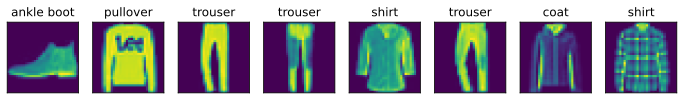

In [37]:
@d2l.add_to_class(FashionMNIST) #@save
def visualize(self, batch, nrows=1, ncols=8, labels=[]):
    X, y = batch
    if not labels:
        labels = self.text_labels(y)
    d2l.show_images(X.squeeze(1), nrows, ncols, titles=labels)
batch = next(iter(data.val_dataloader()))
data.visualize(batch)

###### 4.2.5 Excercises

1) Yes, it took a lot longer to read even though it was only one image. This is because instead of reading 64 at a time it had to read 1 at a time which is more computationally expensive. An epoch runs through the entire dataset, but changes it (data_size)/(batch_size) amount of times.
2 and 3) To complete in the future 

#### 4.3 The Base Classification Model

In [38]:
import torch
from d2l import torch as d2l

In [41]:
class Classifier(d2l.Module): #@save
    """The base class of classification models."""
    def validation_step(self, batch):
        Y_hat = self(*batch[:-1])
        self.plot('loss', self.loss(Y_hat, batch[-1]), train=False)
        self.plot('acc', self.accuracy(Y_hat, batch[-1]), train=False)


In [39]:
@d2l.add_to_class(d2l.Module) #@save
def configure_optimizers(self):
    return torch.optim.SGD(self.parameters(), lr=self.lr)

In [ ]:
@d2l.add_to_class(Classifier) #@save
def accuracy(self, Y_hat, Y, averaged=True):
    """Compute the number of correct predictions."""
    Y_hat = Y_hat.reshape((-1, Y_hat.shape[-1]))
    preds = Y_hat.argmax(axis=1).type(Y.dtype)
    compare = (preds == Y.reshape(-1)).type(torch.float32)
    return compare.mean() if averaged else compare
'''
Y_hat is a matrix of the probabilites that is each class 
take the maximum of each row  = pred
return the average comparing that they got 
'''

##### 4.3.4 Excercises 
1) done on scrap paper 
Ill come backto these im really confused 

#### 4.4 Softmax Regression Implementation from Scratch

In [42]:
X = torch.tensor([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]])
X.sum(0, keepdims=True), X.sum(1, keepdims=True)

(tensor([[5., 7., 9.]]),
 tensor([[ 6.],
         [15.]]))

In [70]:
def softmax(X):
    X_max = X.max()
    X_exp = torch.exp(X-X_max)
    partition = X_exp.sum(1, keepdims = True)
    return X_exp / partition 
#do not build your own softmax like this 
#torch has built in softmax:
X = torch.rand((2,5))
X_prob = softmax(X)
X_prob, X_prob.sum(1) #.sum(1) note is the sum of each row


(tensor([[0.1272, 0.2588, 0.2770, 0.1636, 0.1733],
         [0.2154, 0.1830, 0.2453, 0.2250, 0.1314]]),
 tensor([1.0000, 1.0000]))

In [ ]:
class SoftmaxRegressionScratch(d2l.Classifier):
    def __init__(self, num_inputs, num_outputs, lr, sigma=0.01):
        super().__init__()
        self.save_hyperparameters()
        self.W = torch.normal(0, sigma, size=(num_inputs, num_outputs),requires_grad=True)
        # initialize weights with gaussian noise
        self.b = torch.zeros(num_outputs, requires_grad=True)
        # intialize bias to be zeros 
    def parameters(self):
        return [self.W, self.b]
#note that we have images of pixel size 28 by 28 
# however we will flatten these into 784 x 1 vectors 


In [48]:
@d2l.add_to_class(SoftmaxRegressionScratch)
def forward(self, X):
    X = X.reshape((-1, self.W.shape[0]))
    return softmax(torch.matmul(X, self.W) + self.b)
# first reshaping to be the same way as the first row of the weights 
# matmul (im guessing is matrix multiply) X and tghe weights then add the bias
# softmax this to get each row to add up to 1 and be nonnegative

In [ ]:
'''
Recall cross entropy takes the negative log likelihood of the predicted probability assigned to the true label 
'''

y = torch.tensor([0,2])
y_hat = torch.tensor([[0.1,0.3,0.6], [0.3,0.2,0.5]])
y_hat[[0,1], y]
# above is an efficient way to pick out terms
# y is the true label
#0,1 in y_hat last line is like the 0 and 1 part in the torch.tensor 

tensor([0.1000, 0.5000])

In [ ]:
def cross_entropy(y_hat, y):
    return -torch.log(y_hat[list(range(len(y_hat))), y]).mean()
# take the log of the probability we want
# and take the mean to get the error
# notice -log(1) = 0 
cross_entropy(y_hat, y)

tensor(1.4979)

In [50]:
@d2l.add_to_class(SoftmaxRegressionScratch)
def loss(self, y_hat, y):
    return cross_entropy(y_hat, y)


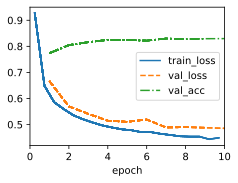

In [51]:
data = d2l.FashionMNIST(batch_size=256)
model = SoftmaxRegressionScratch(num_inputs=784, num_outputs=10, lr=0.1)
trainer = d2l.Trainer(max_epochs=10)
trainer.fit(model, data)

In [52]:
X, y = next(iter(data.val_dataloader()))
preds = model(X).argmax(axis=1)
preds.shape


torch.Size([256])

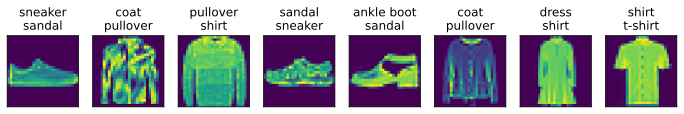

In [53]:
wrong = preds.type(y.dtype) != y
X, y, preds = X[wrong], y[wrong], preds[wrong]
labels = [a+'\n'+b for a, b in zip(
    data.text_labels(y), data.text_labels(preds))]
data.visualize([X, y], labels=labels)

##### 4.4.7 Excercises 


In [71]:
y = torch.tensor([[100.0, 80.0 , -80.0, -100.0]])
softmax(y)
#above 100 becomes nan
# below -100 becomes 0
# we have to subtract the max

tensor([[1.0000e+00, 2.0612e-09, 0.0000e+00, 0.0000e+00]])

#### 4.5 Concise Implementation of Softmax Regression

In [54]:
import torch
from torch import nn
from torch.nn import functional as F
from d2l import torch as d2l


In [55]:
class SoftmaxRegression(d2l.Classifier): #@save
    def __init__(self, num_outputs, lr):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(nn.Flatten(), nn.LazyLinear(num_outputs))
        
def forward(self, X):
    return self.net(X)


In [ ]:
'''
if the largest term in o lies outside the interval [-90,90]
the result will not be stable (overflow, underflow)
a way around this problem is to subtract o(bar) = max_ko_k from all entries
yhat = exp(o_j-obar)/ sum_overk(exp(o_k-o_bar)

by combining softmax and cross entropy 
log y_hat = o_j - obar - log(sum(exp(o_k - obar)))
this avoids both overflow and underflow 
'''

In [56]:
@d2l.add_to_class(d2l.Classifier) #@save
def loss(self, Y_hat, Y, averaged=True):
    Y_hat = Y_hat.reshape((-1, Y_hat.shape[-1]))
    Y = Y.reshape((-1,))
    return F.cross_entropy(
        Y_hat, Y, reduction='mean' if averaged else 'none')


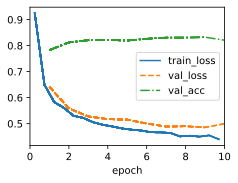

In [57]:
data = d2l.FashionMNIST(batch_size=256)
model = SoftmaxRegression(num_outputs=10, lr=0.1)
trainer = d2l.Trainer(max_epochs=10)
trainer.fit(model, data)